# Predicción del precio de un auto usado

In [120]:
# Librerías de Python

import numpy as np #Programación vectorial
import pandas as pd #Estructura y manipulación de datos
import matplotlib.pyplot as plt #Visualización

import seaborn as sb #Gráficos

import warnings #Advertencias
warnings.filterwarnings('ignore')

In [121]:
# Abrir archivo excel

df = pd.read_excel("df_automotora_preprocesado_EA.xlsx")

## Análisis exploratorio

In [123]:
# Lista de columnas
df.columns

Index(['ID', 'Fecha_Venta', 'Ciudad', 'Region', 'Marca', 'Tipo', 'Modelo',
       'Color', 'Año_Fabricacion', 'Kilometraje', 'Antigüedad', 'Combustible',
       'Transmision', 'Equipamiento', 'Precio_Venta', 'Metodo_Pago',
       'Tipo_Garantia', 'Vencimiento_Garantia', 'Vigencia_Garantia'],
      dtype='object')

In [124]:
#Primeros registros
df.head()

,ID,Fecha_Venta,Ciudad,Region,Marca,Tipo,Modelo,Color,Año_Fabricacion,Kilometraje,Antigüedad,Combustible,Transmision,Equipamiento,Precio_Venta,Metodo_Pago,Tipo_Garantia,Vencimiento_Garantia,Vigencia_Garantia
0,1,2020-01-01,Punta Arenas,Magallanes,Suzuki,SUV,Vitara,Plata,2023,20966.0,2.000000,Gasolina,Automática,Básico,15647640,leasing,1 año,2021-01-01,Vencida
1,2,2020-01-01,Coquimbo,Coquimbo,Peugeot,Hatchback,208,Rojo,2021,46558.0,9.998996,Diésel,Automática,Medio,6243702,credito,6 meses,2020-07-01,Vencida
2,4,2020-01-01,Talca,Maule,Nissan,Sedán,Versa,Verde,2016,97113.0,9.000000,Gasolina,Automática,Básico,5366021,credito,1 año,2021-01-01,Vencida
3,7,2020-01-01,Las Condes,Metropolitana,Suzuki,Sedán,Baleno,Blanco,2014,138689.0,6.000000,Gasolina,Automática,Medio,4352676,credito,Sin Garantía,2020-01-01,Vencida
4,8,2020-01-01,Maipú,Metropolitana,Toyota,Sedán,Corolla,Gris,2005,242320.0,15.000000,Gasolina,Manual,Básico,2093080,credito,Sin Garantía,2020-01-01,Vencida


In [125]:
#Tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53727 entries, 0 to 53726
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    53727 non-null  int64         
 1   Fecha_Venta           53727 non-null  datetime64[ns]
 2   Ciudad                53727 non-null  object        
 3   Region                53727 non-null  object        
 4   Marca                 53727 non-null  object        
 5   Tipo                  53727 non-null  object        
 6   Modelo                53727 non-null  object        
 7   Color                 53727 non-null  object        
 8   Año_Fabricacion       53727 non-null  int64         
 9   Kilometraje           53727 non-null  float64       
 10  Antigüedad            53727 non-null  float64       
 11  Combustible           53727 non-null  object        
 12  Transmision           53727 non-null  object        
 13  Equipamiento    

In [126]:
## Selección de columnas que no son atingentes a modelos predictivos (variables no numéricas)

df = df.drop(
    columns=[
        "ID",
        "Fecha_Venta",
        "Año_Fabricacion",
        "Vencimiento_Garantia"])

In [127]:
#Corroboramos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53727 entries, 0 to 53726
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ciudad             53727 non-null  object 
 1   Region             53727 non-null  object 
 2   Marca              53727 non-null  object 
 3   Tipo               53727 non-null  object 
 4   Modelo             53727 non-null  object 
 5   Color              53727 non-null  object 
 6   Kilometraje        53727 non-null  float64
 7   Antigüedad         53727 non-null  float64
 8   Combustible        53727 non-null  object 
 9   Transmision        53727 non-null  object 
 10  Equipamiento       53727 non-null  object 
 11  Precio_Venta       53727 non-null  int64  
 12  Metodo_Pago        53727 non-null  object 
 13  Tipo_Garantia      53727 non-null  object 
 14  Vigencia_Garantia  53727 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 6.1+ MB


## **1. PREPARACIÓN DE DATOS**

### **1.1. Encoding**

Transformación de las variables categóricas a numéricas discretas. Se reemplazan las clases de cada variable por un código numérico.

Para las variables `Tipo_Garantia`, `Vigencia_Garantia` y `Equipamiento` se aplica una codificación manual, 
porque tienen un orden lógico o una escala natural (por ejemplo, más meses de garantía o mayor nivel de 
equipamiento implica un valor mayor). Para el resto de las variables categóricas (Ciudad, Marca, Modelo, etc.), 
que no tienen un orden natural entre sus categorías, se usará más adelante `LabelEncoder` de forma automática.

In [128]:
#Valores unicos de la variable 'Tipo_Garantia'
df['Tipo_Garantia'].unique()

array(['1 año', '6 meses', 'Sin Garantía', '2 años extendida'],
      dtype=object)

In [129]:
#Reemplazando valores binarios 'Tipo_Garantia'
df['Tipo_Garantia'].replace({
    "Sin Garantía"     :0,
    "1 año"            :12,
    "6 meses"          : 6,
    "2 años extendida" :24,
    }, inplace=True)

In [130]:
#Valores unicos de la variable 'Vigencia_Garantia'
df['Vigencia_Garantia'].unique()

array(['Vencida', 'Vigente'], dtype=object)

In [131]:
#Reemplazando valores binarios 'Vigencia_Garantia'
df['Vigencia_Garantia'].replace({
    "Vencida"     :0,
    "Vigente"     :1,
    }, inplace=True)

In [132]:
#Valores unicos de la variable 'Equipamiento'
df['Equipamiento'].unique()

array(['Básico', 'Medio', 'Full'], dtype=object)

In [133]:
#Reemplazando valores binarios 'Equipamiento'
df['Equipamiento'].replace({
    "Básico"     :1,
    "Medio"     :2,
    "Full"     :3,
    }, inplace=True)

In [134]:
# Lista de columnas
df.columns

Index(['Ciudad', 'Region', 'Marca', 'Tipo', 'Modelo', 'Color', 'Kilometraje',
       'Antigüedad', 'Combustible', 'Transmision', 'Equipamiento',
       'Precio_Venta', 'Metodo_Pago', 'Tipo_Garantia', 'Vigencia_Garantia'],
      dtype='object')

Transformación automática

`LabelEncoder` asigna un número entero a cada categoría de forma arbitraria (no representa un orden real). 
Esto es una limitación a tener en cuenta: para modelos como la regresión lineal, ese número podría 
interpretarse erróneamente como si tuviera una relación de magnitud, mientras que para modelos basados 
en árboles (Árbol de Decisión, Random Forest) esto no representa un problema tan grande.

In [135]:
from sklearn.preprocessing import LabelEncoder
#Selecciona las columnas categóricas que se van a codificar
categorical_cols = ['Ciudad', 
                    'Region', 
                    'Marca', 
                    'Tipo', 
                    'Modelo', 
                    'Color',  
                    'Combustible', 
                    'Transmision', 
                    'Metodo_Pago']

#Itera sobre las columnas categóricas y aplica LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#Muestra los valores originales y los valores codificados
for col in categorical_cols:
    original_values = df[col]
    encoded_values = df[col]
    le = label_encoders[col]

    unique_values = original_values.unique()
    unique_encoded_values = le.inverse_transform(unique_values)

    mapping = dict(zip(unique_values, unique_encoded_values))
    print(f"Columna: {col}")
    print("Valor Codificado - Clase")
    for value, encoded_value in mapping.items():
        print(f"{value} - {encoded_value}")
    print("------------------------")

Columna: Ciudad
Valor Codificado - Clase
22 - Punta Arenas
6 - Coquimbo
27 - Talca
13 - Las Condes
16 - Maipú
15 - Los Ángeles
31 - Valparaíso
23 - Quillón
28 - Temuco
32 - Villarrica
0 - Antofagasta
34 - Viña del Mar
4 - Concepción
17 - Osorno
33 - Vitacura
21 - Puerto Varas
3 - Chillán
12 - La Unión
19 - Providencia
10 - La Dehesa
20 - Puerto Montt
30 - Vallenar
11 - La Serena
5 - Copiapó
18 - Pozo Almonte
2 - Calama
24 - Rancagua
8 - Curicó
9 - Iquique
25 - San Fernando
1 - Arica
26 - Santiago
14 - Linares
7 - Coyhaique
29 - Valdivia
------------------------
Columna: Region
Valor Codificado - Clase
9 - Magallanes
6 - Coquimbo
10 - Maule
11 - Metropolitana
5 - Biobío
15 - Valparaíso
16 - Ñuble
1 - Araucanía
0 - Antofagasta
7 - Los Lagos
8 - Los Ríos
3 - Atacama
14 - Tarapacá
13 - O’Higgins
2 - Arica y Parinacota
4 - Aysén
12 - O'Higgins
------------------------
Columna: Marca
Valor Codificado - Clase
7 - Suzuki
6 - Peugeot
5 - Nissan
8 - Toyota
9 - Volkswagen
2 - Hyundai
1 - Ford
3 -



---



### **1.2. Definición de variables**

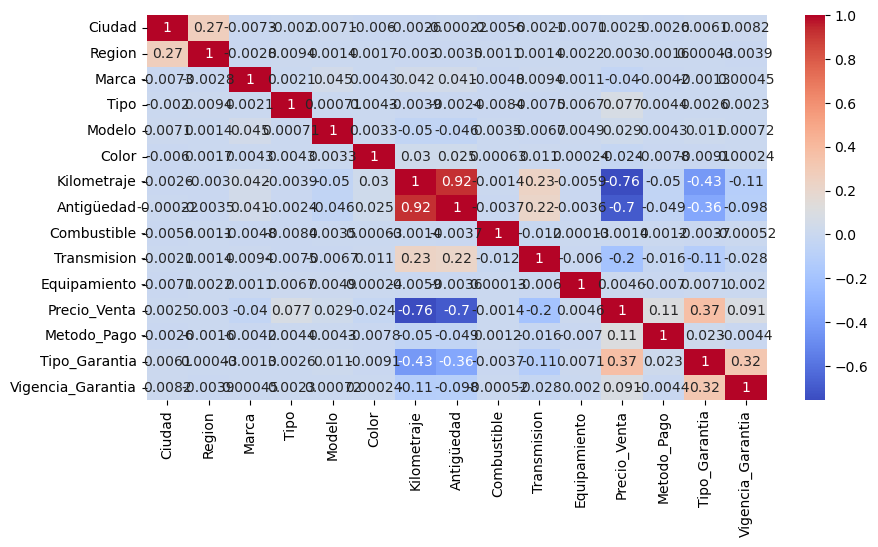

In [136]:
corr = df.corr()
plt.figure(figsize=(10,5))
sb.heatmap(corr, cmap="coolwarm",annot=True)
plt.show()

El mapa de correlación muestra que, en general, la mayoría de las variables presentan relaciones bajas entre sí, lo que indica que no existe una dependencia fuerte entre ellas. Sin embargo, destacan algunas correlaciones importantes: Kilometraje y Antigüedad presentan una correlación positiva muy alta de 0,92, mientras que Precio_Venta tiene una relación negativa con Kilometraje (-0,76) y con Antigüedad (-0,70).

Por lo tanto, se van a eliminar las siguientes variables, ya que no son significativas...

Vigencia_Garantia, Metodo_Pago, Transmision, Equipamiento, Combustible, Color, Modelo, Marca, Region, Ciudad

El criterio usado fue eliminar toda variable cuya correlación (en valor absoluto) con Precio_Venta 
fuera menor al 20%.

Definimos la variable objetivo $Y$ (dependiente) y las variables predictoras $X$ (independientes).

In [137]:
#Variable dependiente
Y = pd.DataFrame(df['Precio_Venta'])
Y.head()

,Precio_Venta
0,15647640
1,6243702
2,5366021
3,4352676
4,2093080


In [138]:
#Variables independientes
X = df.drop(columns=['Precio_Venta',
                     'Vigencia_Garantia',
                     'Equipamiento',
                     'Combustible',
                     'Color',
                     'Modelo',
                     'Marca',
                     'Region',
                     'Ciudad',
                     'Metodo_Pago',
                     'Transmision'
                    ])
X.head()

,Tipo,Kilometraje,Antigüedad,Tipo_Garantia
0,3,20966.0,2.000000,12
1,1,46558.0,9.998996,6
2,4,97113.0,9.000000,12
3,4,138689.0,6.000000,0
4,4,242320.0,15.000000,0


In [139]:
from sklearn.model_selection import train_test_split

In [140]:
#Se define una proporcion 80/20, es decir un tamaño del conjunto de prueba de 0.2 (20%)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2, random_state=123)

In [141]:
#Conjunto de entrenamiento
print(Xtrain.shape)
print(Ytrain.shape)

(42981, 4)
(42981, 1)


In [142]:
#Conjunto de prueba
print(Xtest.shape)
print(Ytest.shape)

(10746, 4)
(10746, 1)


## **2. MODELOS DE REGRESIÓN**

### **2.1. Regresión Lineal**

#### **Modelo 1**

La regresión lineal busca la combinación lineal de las variables X que mejor explica la variable Y, 
minimizando el error cuadrático entre el valor observado y el estimado. Es el modelo más simple e 
interpretable, pero asume relaciones lineales entre las variables.

In [143]:
from sklearn.linear_model import LinearRegression

In [144]:
modelo_1 = LinearRegression()

In [145]:
modelo_1.fit(Xtrain, Ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [146]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_1.predict(Xtest)

In [147]:
# Tabla comparativa
Ytest = Ytest.rename(columns={'Precio_Venta': 'Observación (Y)'})
Y_hat = pd.DataFrame(Y_hat, columns = ['Estimación (Ŷ)'])
Comparacion = pd.merge(Ytest, Y_hat, left_index=True, right_index=True)
Comparacion["Diferencia"] = Comparacion["Observación (Y)"]-Comparacion["Estimación (Ŷ)"]
Comparacion.head(10)

,Observación (Y),Estimación (Ŷ),Diferencia
5814,2050193,9.838708e+06,-7.788515e+06
3528,3331226,9.537340e+06,-6.206114e+06
4805,2608853,4.103406e+06,-1.494553e+06
8312,4258436,4.502729e+06,-2.442927e+05
4161,1721035,8.192109e+06,-6.471074e+06
3539,3535093,6.239276e+06,-2.704183e+06
3293,8196637,4.930269e+06,3.266368e+06
5012,1166809,9.277606e+06,-8.110797e+06
1029,3750270,6.549647e+06,-2.799377e+06
2491,2133663,1.715749e+06,4.179144e+05


✅ Paso 4 - Métricas: Evaluamos el desempeño del modelo a través del cálculo de métricas.

In [148]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tools.eval_measures import rmse

In [149]:
MAE_1 = mean_absolute_error(Ytest, Y_hat)
MSE_1 =  mean_squared_error(Ytest, Y_hat)
RMSE_1 = rmse(Ytest, Y_hat)
r2_1 = r2_score(Ytest, Y_hat)

print("MAE: %.2f" % MAE_1)
print("MSE: %.2f" % MSE_1)
print("RMSE: %.2f" % RMSE_1)
print('r2: %.2f' % r2_1)

MAE: 1584202.64
MSE: 4190252086361.75
RMSE: 2047010.52
r2: 0.58


r² = 0.58: el modelo explica el 58% de la variabilidad del precio, un ajuste moderado.

MAE (~1.58M) y RMSE (~2.05M) muestran un error considerable, y la brecha entre ambos indica presencia de errores grandes puntuales (outliers).

### **2.2. Árbol de Decisión**

Un árbol de decisión divide los datos en subgrupos sucesivos según los valores de las variables X, 
buscando en cada división reducir el error de predicción. A diferencia de la regresión lineal, puede 
capturar relaciones no lineales entre las variables.

#### **Modelo 2**

In [150]:
from sklearn.tree import DecisionTreeRegressor

In [151]:
modelo_2 = DecisionTreeRegressor()

In [152]:
modelo_2.fit(Xtrain, Ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [153]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_2.predict(Xtest)

In [154]:
import math

In [155]:
MAE_2 = mean_absolute_error(Ytest, Y_hat)
MSE_2 =  mean_squared_error(Ytest, Y_hat)
RMSE_2 = math.sqrt(mean_squared_error(Ytest, Y_hat))
r2_2 = r2_score(Ytest, Y_hat)

print("MAE: %.2f" % MAE_2)
print("MSE: %.2f" % MSE_2)
print("RMSE: %.2f" % RMSE_2)
print('r2: %.2f' % r2_2)

MAE: 710484.43
MSE: 804226395056.14
RMSE: 896786.71
r2: 0.92


r² = 0.92: el modelo explica el 92% de la variabilidad del precio, un ajuste muy alto.

MAE (~710K) y RMSE (~897K) muestran un error bajo, considerablemente menor que en el modelo anterior, aunque la brecha entre ambos sigue indicando presencia de algunos errores grandes puntuales (outliers).

#### **Modelo 3**

In [156]:
modelo_3 = DecisionTreeRegressor(max_depth=12, min_samples_split=3, min_samples_leaf=3)

In [157]:
modelo_3.fit(Xtrain, Ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,12
,min_samples_split,3
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [158]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_3.predict(Xtest)

In [159]:
MAE_3 = mean_absolute_error(Ytest, Y_hat)
MSE_3 =  mean_squared_error(Ytest, Y_hat)
RMSE_3 = math.sqrt(mean_squared_error(Ytest, Y_hat))
r2_3 = r2_score(Ytest, Y_hat)
print("MAE: %.2f" % MAE_3)
print("MSE: %.2f" % MSE_3)
print("RMSE: %.2f" % RMSE_3)
print('r2: %.2f' % r2_3)

MAE: 536508.83
MSE: 462255073443.06
RMSE: 679893.43
r2: 0.95


r² = 0.95: el modelo explica el 95% de la variabilidad del precio, un ajuste muy alto.

MAE (~537K) y RMSE (~680K) muestran un error bajo, menor que en el modelo anterior, aunque la brecha entre ambos sigue indicando presencia de algunos errores grandes puntuales (outliers).

### **2.3. K-Nearest Neighbors (KNN)**

#### **Modelo 4**

KNN (K-Nearest Neighbors) estima el valor de Y para un caso nuevo promediando el valor de sus K vecinos 
más cercanos en el espacio de las variables X, según una métrica de distancia. Es un modelo no paramétrico: 
no asume una forma funcional para la relación entre X e Y.

In [160]:
from sklearn.neighbors import KNeighborsRegressor

In [161]:
modelo_4 = KNeighborsRegressor(n_neighbors=5)

In [162]:
modelo_4.fit(Xtrain, Ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [163]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_4.predict(Xtest)

Con este modelo se predece el precio de una casa basado en las características de automoviles similares.

In [164]:
MAE_4 = mean_absolute_error(Ytest, Y_hat)
MSE_4 =  mean_squared_error(Ytest, Y_hat)
RMSE_4 = rmse(Ytest, Y_hat)
r2_4 = r2_score(Ytest, Y_hat)

print("MAE: %.2f" % MAE_4)
print("MSE: %.2f" % MSE_4)
print("RMSE: %.2f" % RMSE_4)
print('r2: %.2f' % r2_4)

MAE: 1585059.20
MSE: 4526297055488.41
RMSE: 2127509.59
r2: 0.55


r² = 0.55: el modelo explica el 55% de la variabilidad del precio, un ajuste moderado.

MAE (~1.59M) y RMSE (~2.13M) muestran un error considerable, y la brecha entre ambos indica presencia de errores grandes puntuales (outliers).

#### **Modelo 5**

In [165]:
from sklearn.model_selection import GridSearchCV

In [166]:
# Definir la lista de hiperparámetros a probar
matriz = {
    'n_neighbors': [3, 5, 7, 9, 12],  # Valores de K
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Métricas de distancia
}

# Crear el modelo KNN Regressor
modelo = KNeighborsRegressor()

# Realizar la búsqueda en cuadrícula
grid_search = GridSearchCV(estimator=modelo, param_grid=matriz, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(Xtrain, Ytrain)  # X_train y y_train son tus datos de entrenamiento

# Obtener los mejores hiperparámetros
mejores = grid_search.best_params_
mejores

{'metric': 'manhattan', 'n_neighbors': 12}

In [167]:
# Crear un nuevo modelo KNN Regressor con los mejores parámetros
mejor_k = mejores['n_neighbors']  # Mejor valor de K
mejor_metric = mejores['metric']  # Mejor métrica de distancia

modelo_5 = KNeighborsRegressor(n_neighbors=mejor_k, metric=mejor_metric, weights='distance')

In [168]:
modelo_5.fit(Xtrain, Ytrain)

,n_neighbors,12
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [169]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_5.predict(Xtest)

In [170]:
MAE_5 = mean_absolute_error(Ytest, Y_hat)
MSE_5 =  mean_squared_error(Ytest, Y_hat)
RMSE_5 = rmse(Ytest, Y_hat)
r2_5 = r2_score(Ytest, Y_hat)

print("MAE: %.2f" % MAE_5)
print("MSE: %.2f" % MSE_5)
print("RMSE: %.2f" % RMSE_5)
print('r2: %.2f' % r2_5)

MAE: 1515674.04
MSE: 4129662492615.56
RMSE: 2032157.10
r2: 0.59


r² = 0.59: el modelo explica el 59% de la variabilidad del precio, un ajuste moderado.

MAE (~1.52M) y RMSE (~2.03M) muestran un error considerable, y la brecha entre ambos indica presencia de errores grandes puntuales (outliers).

### **2.4. Random Forest**

#### **Modelo 6**

Random Forest construye muchos árboles de decisión entrenados sobre distintas muestras de los datos y 
promedia sus predicciones. Esto reduce el sobreajuste que puede tener un árbol individual y suele mejorar 
la capacidad de generalización.

In [171]:
from sklearn.ensemble import RandomForestRegressor

In [172]:
modelo_6 = RandomForestRegressor(n_estimators=100, max_depth=10)

In [173]:
modelo_6.fit(Xtrain, Ytrain)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [174]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_6.predict(Xtest)

In [175]:
MAE_6 = mean_absolute_error(Ytest, Y_hat)
MSE_6 =  mean_squared_error(Ytest, Y_hat)
RMSE_6 = math.sqrt(mean_squared_error(Ytest, Y_hat))
r2_6 = r2_score(Ytest, Y_hat)

print("MAE: %.2f" % MAE_6)
print("MSE: %.2f" % MSE_6)
print("RMSE: %.2f" % RMSE_6)
print('r2: %.2f' % r2_6)

MAE: 510521.52
MSE: 412933622705.08
RMSE: 642599.12
r2: 0.96


r² = 0.96: el modelo explica el 96% de la variabilidad del precio, un ajuste muy alto.

MAE (~511K) y RMSE (~643K) muestran un error bajo, el más bajo visto hasta ahora, aunque la brecha entre ambos sigue indicando presencia de algunos errores grandes puntuales (outliers).

#### **Modelo 7**

✅ Paso 1 - Modelo: Creación del modelo Random Forest.

In [176]:
# Ajuste de hiperparámetros utilizando GridSearchCV
matriz = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Crear una instancia del modelo Random Forest
modelo = RandomForestRegressor(random_state=123)

# Utilizar GridSearchCV para encontrar la mejor combinación de hiperparámetros
grid_search = GridSearchCV(estimator=modelo, param_grid=matriz, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(Xtrain, Ytrain)

# Obtener la mejor combinación de hiperparámetros
mejores = grid_search.best_params_
mejores

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [181]:
# Crear un modelo Random Forest con los mejores parámetros
modelo_7 = RandomForestRegressor(**mejores, random_state=123)

'''
Se utiliza el doble asterisco (**) para desempaquetar el diccionario de hiperparámetros
(mejores) y pasarlos como argumentos individuales al constructor del modelo.
'''

'\nSe utiliza el doble asterisco (**) para desempaquetar el diccionario de hiperparámetros\n(mejores) y pasarlos como argumentos individuales al constructor del modelo.\n'

In [182]:
modelo_7.fit(Xtrain, Ytrain)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [183]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_7.predict(Xtest)

In [184]:
MAE_7 = mean_absolute_error(Ytest, Y_hat)
MSE_7 =  mean_squared_error(Ytest, Y_hat)
RMSE_7 = math.sqrt(mean_squared_error(Ytest, Y_hat))
r2_7 = r2_score(Ytest, Y_hat)

print("MAE: %.2f" % MAE_7)
print("MSE: %.2f" % MSE_7)
print("RMSE: %.2f" % RMSE_7)
print('r2: %.2f' % r2_7)

MAE: 511196.38
MSE: 414327677887.50
RMSE: 643682.90
r2: 0.96


r² = 0.96: el modelo explica el 96% de la variabilidad del precio, un ajuste muy alto.

MAE (~511K) y RMSE (~644K) muestran un error bajo, prácticamente igual al modelo anterior, aunque la brecha entre ambos sigue indicando presencia de algunos errores grandes puntuales (outliers).

### **2.5. Support Vector Machines (SVM)**

SVM (Support Vector Regression) busca una función que mantenga los errores de predicción dentro de un 
margen de tolerancia, penalizando los que quedan fuera. Es un modelo sensible a la escala de las variables.

#### **Modelo 8**



In [185]:
from sklearn.svm import SVR

In [186]:
modelo_8 = SVR()

In [187]:
modelo_8.fit(Xtrain, Ytrain)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [188]:
#Estimacion de Y (Y "gorro")
Y_hat = modelo_8.predict(Xtest)

In [189]:
MAE_8 = mean_absolute_error(Ytest, Y_hat)
MSE_8 = mean_squared_error(Ytest, Y_hat)
RMSE_8 = np.sqrt(MSE_8)
r2_8 = r2_score(Ytest, Y_hat)

print("MAE: %.2f" % MAE_8)
print("MSE: %.2f" % MSE_8)
print("RMSE: %.2f" % RMSE_8)
print('r2: %.2f' % r2_8)

MAE: 2506669.08
MSE: 10307063639202.51
RMSE: 3210461.59
r2: -0.03


r² = -0.03: el modelo tiene un ajuste prácticamente nulo, incluso peor que simplemente predecir el promedio de los precios.

MAE (~2.51M) y RMSE (~3.21M) muestran un error muy alto, y la brecha entre ambos indica presencia de errores grandes puntuales (outliers).

El desempeño deficiente de SVM probablemente se debe a que no se escalaron las variables antes de 
entrenarlo. SVR es sensible a la escala de los datos, y en este caso Kilometraje (decenas de miles) y 
Antigüedad (unidades) tienen magnitudes muy distintas, lo que perjudica al modelo. 

## **3. EVALUACIÓN DE MODELOS**

In [190]:
tabla = pd.DataFrame({'Métrica':['MAE:','MSE:','RMSE:','r2:'],
                      'Regresión lineal':[MAE_1,MSE_1,RMSE_1,r2_1],
                      'Árbol de Decisión':[MAE_2,MSE_2,RMSE_2,r2_2],
                      'Modelo 3': [MAE_3,MSE_3,RMSE_3,r2_3],
                      'Modelo 4': [MAE_4,MSE_4,RMSE_4,r2_4],
                      'KNN':[MAE_5,MSE_5,RMSE_5,r2_5],
                      'Modelo 6': [MAE_6,MSE_6,RMSE_6,r2_6],
                      'Random Forest':[MAE_7,MSE_7,RMSE_7,r2_7],
                      'SVM': [MAE_8,MSE_8,RMSE_8,r2_8]})

# Definir una función de formato que maneje valores escalares
def format_value(x):
    if isinstance(x, (int, float, np.number)):
        return f"{x:.4f}"
    return x

# Aplicar formato a los valores numéricos
tabla.iloc[:, 1:] = tabla.iloc[:, 1:].applymap(format_value)

# Tabla resultante
tabla

,Métrica,Regresión lineal,Árbol de Decisión,Modelo 3,Modelo 4,KNN,Modelo 6,Random Forest,SVM
0,MAE:,1584202.6419,710484.4342,536508.8279,1585059.2016,1515674.0429,510521.5154,511196.3791,2506669.0769
1,MSE:,4190252086361.7524,804226395056.1427,462255073443.0628,4526297055488.4111,4129662492615.5576,412933622705.0807,414327677887.4960,10307063639202.5078
2,RMSE:,[2047010.5242430368],896786.7054,679893.4280,[2127509.589987413],[2032157.1033302415],642599.1151,643682.9017,3210461.5929
3,r2:,0.5818,0.9197,0.9539,0.5482,0.5878,0.9588,0.9586,-0.0288


Se seleccionó Random Forest (optimizado con GridSearchCV) como modelo final, por su combinación de bajo error y alto poder explicativo, con un r² de 0.96 y errores de predicción considerablemente menores que el resto de las alternativas evaluadas. El modelo se guardó en un archivo .pkl para su reutilización sin necesidad de reentrenarlo.

In [192]:
import joblib

# Guardar el modelo en un archivo
joblib.dump(modelo_7, 'ganador_v2.pkl')

['ganador_v2.pkl']

## **4. IMPLEMENTACIÓN**

Recordando el mapeo obtenido con LabelEncoder en la sección de Encoding (columna "Tipo"), los códigos 
usados a continuación corresponden a: 

Columna: Ciudad
Valor Codificado - Clase
22 - Punta Arenas
6 - Coquimbo
27 - Talca
13 - Las Condes
16 - Maipú
15 - Los Ángeles
31 - Valparaíso
23 - Quillón
28 - Temuco
32 - Villarrica
0 - Antofagasta
34 - Viña del Mar
4 - Concepción
17 - Osorno
33 - Vitacura
21 - Puerto Varas
3 - Chillán
12 - La Unión
19 - Providencia
10 - La Dehesa
20 - Puerto Montt
30 - Vallenar
11 - La Serena
5 - Copiapó
18 - Pozo Almonte
2 - Calama
24 - Rancagua
8 - Curicó
9 - Iquique
25 - San Fernando
1 - Arica
26 - Santiago
14 - Linares
7 - Coyhaique
29 - Valdivia

Columna: Region
Valor Codificado - Clase
9 - Magallanes
6 - Coquimbo
10 - Maule
11 - Metropolitana
5 - Biobío
15 - Valparaíso
16 - Ñuble
1 - Araucanía
0 - Antofagasta
7 - Los Lagos
8 - Los Ríos
3 - Atacama
14 - Tarapacá
13 - O’Higgins
2 - Arica y Parinacota
4 - Aysén
12 - O'Higgins

Columna: Marca
Valor Codificado - Clase
7 - Suzuki
6 - Peugeot
5 - Nissan
8 - Toyota
9 - Volkswagen
2 - Hyundai
1 - Ford
3 - Kia
4 - Mazda
0 - Chevrolet

Columna: Tipo
Valor Codificado - Clase
3 - SUV
1 - Hatchback
4 - Sedán
2 - Pickup
0 - Comercial

Columna: Modelo
Valor Codificado - Clase
46 - Vitara
1 - 208
45 - Versa
7 - Baleno
14 - Corolla
41 - Tiguan
43 - Tucson
27 - Polo
16 - Elantra
18 - Fiesta
12 - Cerato
6 - BT-50
39 - Sportage
40 - Swift
30 - Rav4
48 - Yaris
13 - Colorado
0 - 2008
33 - Sail
24 - Mazda3
31 - Rio
34 - Santa Fe
44 - Vento
3 - 301
9 - CX-5
4 - Accent
23 - Mazda2
42 - Tracker
19 - Focus
22 - March
37 - Sorento
5 - Amarok
36 - Sentra
2 - 3008
21 - Hilux
29 - Ranger
15 - Ecosport
35 - Seltos
47 - X-Trail
26 - Partner
28 - Prado
20 - Gol
38 - Spark
49 - i10
8 - CX-3
10 - Captiva
32 - S-Cross
25 - Navara
11 - Celerio
17 - Escape

Columna: Color
Valor Codificado - Clase
5 - Plata
6 - Rojo
7 - Verde
2 - Blanco
3 - Gris
4 - Negro
0 - Azul
1 - Beige

Columna: Combustible
Valor Codificado - Clase
2 - Gasolina
0 - Diésel
3 - Híbrido
1 - Eléctrico

Columna: Transmision
Valor Codificado - Clase
0 - Automática
1 - Manual

Columna: Metodo_Pago
Valor Codificado - Clase
2 - leasing
1 - credito
0 - contado

In [194]:
import joblib

modelo_ganador = joblib.load('ganador_v2.pkl')

# Ejemplo A: Auto con poco uso
auto_1 = {'Tipo': 2,              # <-- reemplaza por el código real de "Tipo"
          'Kilometraje': 15000,
          'Antigüedad': 1,
          'Tipo_Garantia': 24}
auto_1 = pd.DataFrame(auto_1, index=[0])
pred_1 = modelo_ganador.predict(auto_1)
print(f"Auto 1 (poco uso): precio estimado ${round(float(pred_1),2):,.0f}")

# Ejemplo B: Auto de uso medio
auto_2 = {'Tipo': 0,              # <-- reemplaza por el código real
          'Kilometraje': 60000,
          'Antigüedad': 4,
          'Tipo_Garantia': 12}
auto_2 = pd.DataFrame(auto_2, index=[0])
pred_2 = modelo_ganador.predict(auto_2)
print(f"Auto 2 (uso medio): precio estimado ${round(float(pred_2),2):,.0f}")

# Ejemplo C: Auto antiguo, sin garantía
auto_3 = {'Tipo': 1,              # <-- reemplaza por el código real
          'Kilometraje': 150000,
          'Antigüedad': 10,
          'Tipo_Garantia': 0}
auto_3 = pd.DataFrame(auto_3, index=[0])
pred_3 = modelo_ganador.predict(auto_3)
print(f"Auto 3 (antiguo): precio estimado ${round(float(pred_3),2):,.0f}")

Auto 1 (poco uso): precio estimado $14,725,712
Auto 2 (uso medio): precio estimado $8,500,396
Auto 3 (antiguo): precio estimado $3,353,620


---
---
## **CONCLUSIÓN**


De los 8 algoritmos de regresión puestos a prueba para estimar el precio de venta de vehículos usados, Random Forest con ajuste de hiperparámetros vía GridSearchCV se posicionó como la mejor alternativa, alcanzando un r² de 0.96, es decir, explica prácticamente toda la variación observada en los precios, con un error promedio (MAE) cercano a los $511.196. Este resultado deja en evidencia que el valor de un vehículo usado no responde a una lógica lineal simple, sino a interacciones más complejas entre variables como el kilometraje, la antigüedad, el tipo de vehículo y su cobertura de garantía, algo que los modelos basados en árboles logran modelar con mucha más precisión que un enfoque lineal tradicional.

Al poner el modelo ganador en práctica con tres vehículos hipotéticos (Sección 4), sus estimaciones siguieron un patrón lógico y esperable dentro del rubro automotor:

Un auto con poco uso (15.000 km, 1 año, garantía extendida de 24 meses) obtuvo la valoración más alta: $14.725.712.

Uno con uso intermedio (60.000 km, 4 años, 12 meses de garantía) quedó en un punto medio: $8.500.396.

Uno más antiguo y sin garantía (150.000 km, 10 años) recibió la estimación más baja: $3.353.620.

La relación inversa entre uso/antigüedad y precio, junto con el efecto positivo de contar con garantía, se refleja con claridad en estos tres casos.

## Referencias

- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning 
  Research*, 12, 2825-2830. https://scikit-learn.org/
- McKinney, W. (2010). Data Structures for Statistical Computing in Python. pandas. https://pandas.pydata.org/
- Seaborn: statistical data visualization. https://seaborn.pydata.org/
- Documentación oficial de joblib. https://joblib.readthedocs.io/
- [Agregar aquí la fuente del dataset df_automotora_preprocesado_EA.xlsx, si corresponde]